In [ ]:
#IMPORTING OF LIBRARIES

# utilities
import re
import numpy as np
import pandas as pd
import nltk
import tweepy
from textblob import TextBlob
from wordcloud import WordCloud

# plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# nltk
import nltk
# utilities



your csv files should have 1 column and column should have no title, as such you an give it a tilte using the code below

In [ ]:
#importing dataset
DATASET_COLUMNS = ['Tweets'] #for giving  title to the column
DATASET_ENCODING = 'ISO-8859-1' #file encoding to help with correct errors associated with file encodings
df = pd.read_csv('/content/tweets1.csv' )# here yournread your pdf from its location
df.head() # this is used to read what is in your csv file

,tweet
0,HAPPY FRIDAY GETTOGETHER #BidenHarris2024#Vot...
1,"It's remarkable, isn't it? All of the #BlackLi..."
2,HAPPY THURSDAY GET TOGETHER#BidenHarris2024#Vo...
3,This Supreme Court now has an opportunity to a...
4,THURSDAY GET TOGETHER#BidenHarris2024#VoteBlue...


In [ ]:
#columns in data(to know the colums you have in your data)

df.columns


Index(['tweet'], dtype='object')

In [ ]:

#Removing Duplicates and also helps with data analysis helps identify the distinct tweets in the column,
#which is useful for understanding the diversity of tweets and removing duplicates if necessary
df['tweet'].unique()


array(['HAPPY FRIDAY GETTOGETHER  #BidenHarris2024#VoteBlue#Ukraine️IsNotRussiaIsNotRussia #NigerIsNotFrance #SudanGenocide#AfricanWealthForAfricans#GunControl#BLM #BlackLivesMatter#HumanRights#WomensRights#ClimateLIKEComment RETWEET\nVet&Follow#VoteBlueToSaveDemocracy ',
       "It's remarkable, isn't it? All of the #BlackLivesMatter riots and it's like it never happened.\n\nI would love to know how many convictions there have been for all of the #BLMRiots vs the one riot on #January6.#BLM #DoubleStandards #LiberalHypocrisy",
       'HAPPY THURSDAY GET TOGETHER#BidenHarris2024#VoteBlue2024#BidenDelivers#Ukraine️#NigerForNigeriens#Sudan#GunControl#StopPutin#BLM #BlackLivesMatter#HumanRights#WomensRights#Climate#AfricanWealthForAfricansLIKEComment RETWEETVet&Follow#LoveOverHate',
       'This Supreme Court now has an opportunity to actually help #women instead of continuing its erosion of bodily autonomy.\n\nWe demand that #SCOTUS uphold the FDA’s existing access rules for #mifepristone

In [ ]:
df.tail() # to look at the ending part of your file

,tweet
853,#TakeActionAgainstRacism
854,Hey @UEFA all eyes are (still) on you..... #Ta...
855,Proud of our people seeking #JusticeForColtenB...
856,@Facebook @markzukerbergfb I was the vitim of ...
857,Action can make a difference! #TakeActionAgai...


In Sentiment Analysis, your data must under go data preprocessing to remove noise .

In [ ]:
#MAKING TWEETS LOWER CASE


df['tweet'] =df['tweet'].str.lower()
df['tweet'].tail()


853                             #takeactionagainstracism
854    hey @uefa all eyes are (still) on you..... #ta...
855    proud of our people seeking #justiceforcoltenb...
856    @facebook @markzukerbergfb i was the vitim of ...
857    action can make a difference!  #takeactionagai...
Name: tweet, dtype: object

In [ ]:
#defining list of stopwords
#stop words could be user defined
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs','the', 'that', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves','']

In [ ]:
#REMOVING STOPWORDS
#defined stopwords are used

STOPWORDS = set(stopwordlist)
def cleaning_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
df['tweet'] = df['tweet'].apply(lambda text: cleaning_stopwords(text))
df['tweet'].head()

0    happy friday gettogether #bidenharris2024#vote...
1    it's remarkable, isn't it? #blacklivesmatter r...
2    happy thursday get together#bidenharris2024#vo...
3    supreme court opportunity actually help #women...
4    thursday get together#bidenharris2024#voteblue...
Name: tweet, dtype: object

In [ ]:
df.tail()

,tweet
853,#takeactionagainstracism
854,hey @uefa eyes (still) you..... #takeactionaga...
855,proud people seeking #justiceforcoltenboushie ...
856,@facebook @markzukerbergfb vitim hate crime fb...
857,action make difference! #takeactionagainstracism


In [ ]:
#REMOVING OF PUNCTUATIONS

import string
english_punctuations = string.punctuation
punctuations_list = english_punctuations
def cleaning_punctuations(text):
    translator = str.maketrans('', '', punctuations_list)
    return text.translate(translator)
df['tweet']= df['tweet'].apply(lambda x: cleaning_punctuations(x))
df['tweet'].head()
df['tweet'].tail()

853                              takeactionagainstracism
854      hey uefa eyes still you takeactionagainstracism
855    proud people seeking justiceforcoltenboushie h...
856    facebook markzukerbergfb vitim hate crime fb i...
857       action make difference takeactionagainstracism
Name: tweet, dtype: object

In [ ]:
#CLEANING AND REMOVING REPEATING CHARACTERS

def cleaning_repeating_char(text):
    return re.sub(r'(.)1+', r'1', text)
df['tweet'] = df['tweet'].apply(lambda x: cleaning_repeating_char(x))
df['tweet'].tail()


853                              takeactionagainstracism
854      hey uefa eyes still you takeactionagainstracism
855    proud people seeking justiceforcoltenboushie h...
856    facebook markzukerbergfb vitim hate crime fb i...
857       action make difference takeactionagainstracism
Name: tweet, dtype: object

In [ ]:
#CLEANING AND REMOVING URL'S

def cleaning_URLs(data):
    return re.sub('((www.[^s]+)|(https?://[^s]+))',' ',data)
df['tweet'] = df['tweet'].apply(lambda x: cleaning_URLs(x))
df['tweet'].head()
df['tweet'].tail()

853                              takeactionagainstracism
854      hey uefa eyes still you takeactionagainstracism
855    proud people seeking justiceforcoltenboushie h...
856    facebook markzukerbergfb vitim hate crime fb i...
857       action make difference takeactionagainstracism
Name: tweet, dtype: object

In [ ]:
#REMOVING NUMERIC NUMBERS

def cleaning_numbers(data):
    return re.sub('[0-9]+', '', data)
df['tweet'] = df['tweet'].apply(lambda x: cleaning_numbers(x))
df['tweet'].head()
df['tweet'].tail()

853                              takeactionagainstracism
854      hey uefa eyes still you takeactionagainstracism
855    proud people seeking justiceforcoltenboushie h...
856    facebook markzukerbergfb vitim hate crime fb i...
857       action make difference takeactionagainstracism
Name: tweet, dtype: object

In [ ]:
#applying stemming

import nltk
st = nltk.PorterStemmer()
def stemming_on_text(data):
    text = [st.stem(word) for word in data]
    return data
df['tweet']= df['tweet'].apply(lambda x: stemming_on_text(x))
df['tweet'].head()
df['tweet'].tail()

853                              takeactionagainstracism
854      hey uefa eyes still you takeactionagainstracism
855    proud people seeking justiceforcoltenboushie h...
856    facebook markzukerbergfb vitim hate crime fb i...
857       action make difference takeactionagainstracism
Name: tweet, dtype: object

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
 import nltk
nltk.download()


NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> x

---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> l
Packages:
  [ ] abc................. Australian Broadcasting Commission 2006
  [ ] alpino.............. Alpino Dutch Treebank
  [ ] averaged_perceptron_tagger Averaged Perceptron Tagger
  [ ] averaged_perceptron_tagger_ru Averaged Perceptron Tagger (Russian)
  [ ] basque_grammars..... Grammars for Basque
  [ ] biocreative_ppi..... BioCreAtIvE (Critical Assessment of Information
        

True

In [ ]:

#Creating a function to get the subjectivity

def getSubjectivity(text):
    return TextBlob(text).sentiment.subjectivity

#Create a function to get Polarity

def getPolarity(text):
    return TextBlob(text).sentiment.polarity


#Create two new columns
df['Subjectivity'] =df['tweet'].apply(getSubjectivity)
df['Polarity'] = df['tweet'].apply(getPolarity)


#show the new dataframe with the new columns with Polarity and Subjectivity
df



,tweet,Subjectivity,Polarity
0,happy friday gettogether bidenharrisvoteblueuk...,1.000000,0.800000
1,its remarkable isnt it blacklivesmatter riots ...,0.616667,0.583333
2,happy thursday get togetherbidenharrisvoteblue...,1.000000,0.800000
3,supreme court opportunity actually help women ...,0.100000,0.000000
4,thursday get togetherbidenharrisvoteblueukrain...,0.000000,0.000000
...,...,...,...
853,takeactionagainstracism,0.000000,0.000000
854,hey uefa eyes still you takeactionagainstracism,0.000000,0.000000
855,proud people seeking justiceforcoltenboushie h...,1.000000,0.800000
856,facebook markzukerbergfb vitim hate crime fb i...,0.900000,-0.800000


In [ ]:
#Create a function to compute the negativity and positivity

def getAnalysis(score):
    if score < 0:
        return 'Negativity'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Positive'

df['Analysis'] = df['Polarity'].apply(getAnalysis)


#Showing Dataframe to verify results

df


,tweet,Subjectivity,Polarity,Analysis
0,happy friday gettogether bidenharrisvoteblueuk...,1.000000,0.800000,Positive
1,its remarkable isnt it blacklivesmatter riots ...,0.616667,0.583333,Positive
2,happy thursday get togetherbidenharrisvoteblue...,1.000000,0.800000,Positive
3,supreme court opportunity actually help women ...,0.100000,0.000000,Neutral
4,thursday get togetherbidenharrisvoteblueukrain...,0.000000,0.000000,Neutral
...,...,...,...,...
853,takeactionagainstracism,0.000000,0.000000,Neutral
854,hey uefa eyes still you takeactionagainstracism,0.000000,0.000000,Neutral
855,proud people seeking justiceforcoltenboushie h...,1.000000,0.800000,Positive
856,facebook markzukerbergfb vitim hate crime fb i...,0.900000,-0.800000,Negativity


In [ ]:
#downloading new columns to csv # here you may download sentiment derived using text blob an use it to build an ml model
df.to_csv('df.csv', index=False)

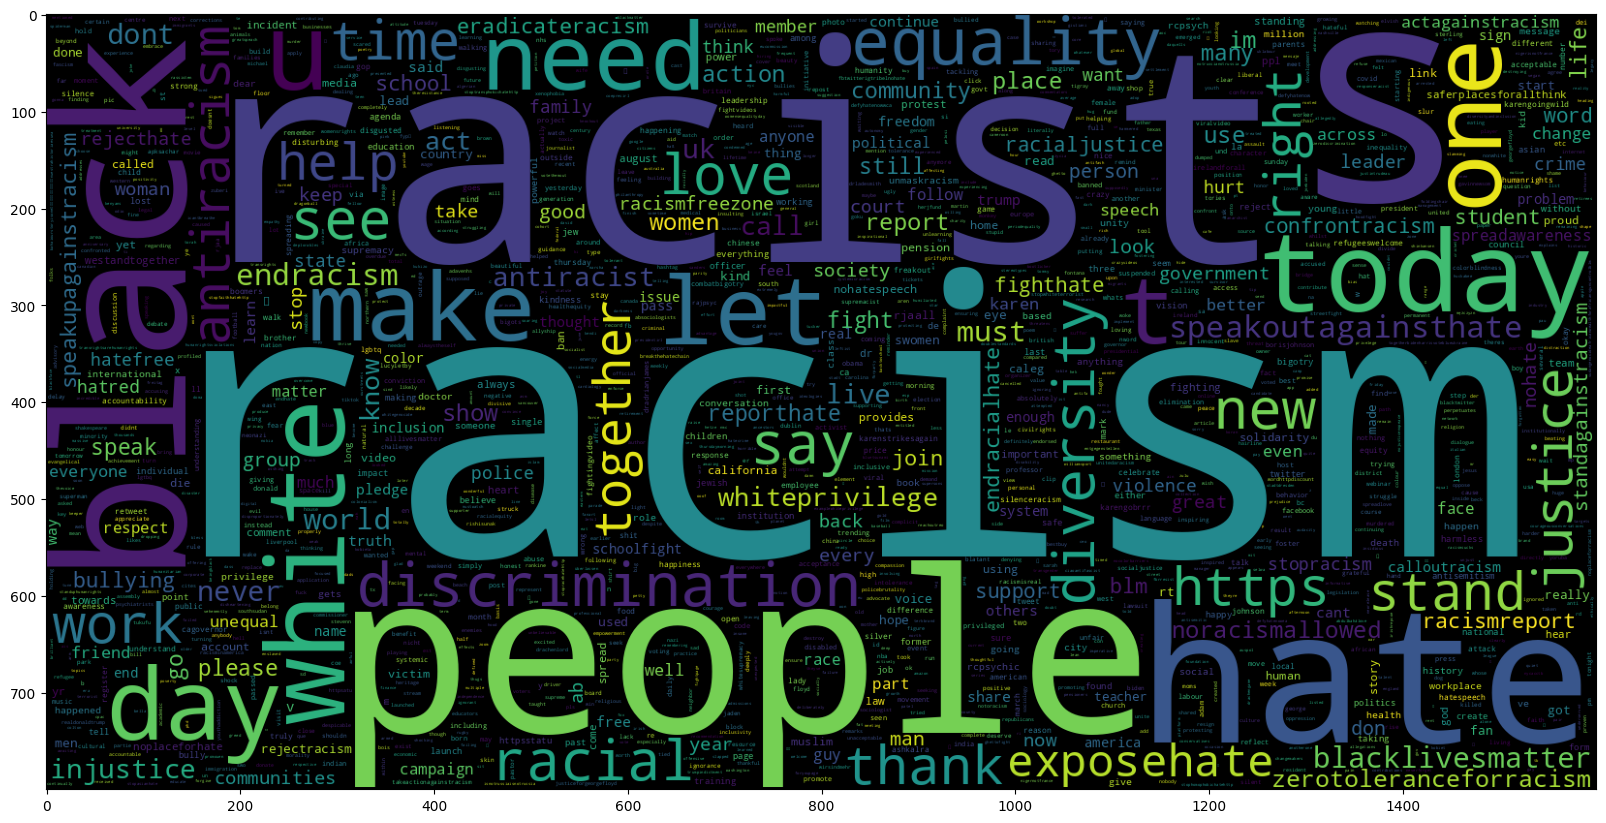

In [ ]:
 #plotting of wordcloud to show words mentioned most

data_neg = df['tweet'][:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 20000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

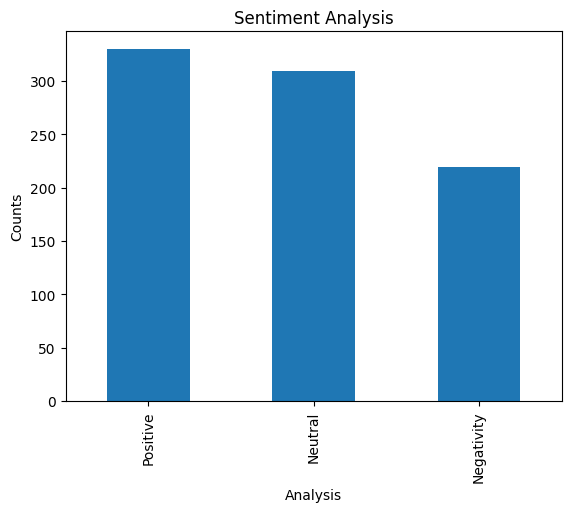

In [ ]:
#showing plot for value counts

df['Analysis'].value_counts()

#plot and visualizing counts

plt.title('Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Counts')
df['Analysis'].value_counts().plot(kind='bar')
plt.show()